# Feature Selection — Reducción de dimensionalidad

**Problema**: con ~60-80 features y 491 observaciones hay sobreajuste.  
**Objetivo**: reducir features manteniendo o mejorando la generalización.

## Métodos aplicados (en orden)

| Paso | Método | Base | Elimina |
|------|--------|------|--------|
| 1 | VIF | Solo X (sin target) | Multicolinealidad |
| 2 | Varianza casi-cero | Solo X | Features sin información |
| 3 | Permutation Importance (RF) | X + y, con CV | Features con baja contribución |
| 4 | RFECV | X + y, con CV | Selección óptima recursiva |
| 5 | Comparación | Todas las estrategias vs baseline | Elección del subconjunto final |

**Regla anti-leakage**: pasos 3-5 usan **solo X_tv** (train+val).  
El test set no se toca hasta el notebook 05.

**Output**: `data/selected_features.json` — lista de features seleccionadas

## Nota v5 — Estrategia de selección

En v5 las variables de conteo por competencia (`n_asignaturas__*`, `n_suspensos__*`)
fueron **eliminadas en NB02** y reemplazadas por porcentajes:
- `pct_asignaturas__X`: qué fracción de las materias del alumno pertenece a la competencia X
- `pct_aprobado__X`: porcentaje de aprobados en la competencia X (sin cambio)

Por tanto **no es necesario eliminar manualmente los conteos** antes del VIF:
el dataset de entrada ya solo contiene variables comparables entre alumnos
independientemente de su carga lectiva.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import f1_score
import sys
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Detectar raiz TFM desde cualquier subcarpeta
_cwd = Path('.').resolve()
BASE_DIR = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / 'data').exists()),
    _cwd.parent
)
sys.path.append(str(BASE_DIR))
from src.utils.metrics import scorer_academico
P_IN      = BASE_DIR / 'data' / 'dataset_v11_fe.csv'
P_OUT_FEATURES = BASE_DIR / 'data' / 'selected_features_v11.json'
SEED      = 42
CV        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
CAT_ORDER = ['buen_alumno', 'en_riesgo', 'con_dificultades']

df = pd.read_csv(P_IN)
EXCLUIR   = {'target_num', 'categoria_target'}
feat_cols = [c for c in df.select_dtypes(include='number').columns if c not in EXCLUIR]

# ── Curación conceptual ANTES del VIF ────────────────────────────────────────
# El VIF ciego elimina TODAS las notas (están intercorrelacionadas), dejando el
# modelo sin las variables que la teoría señala como las más predictivas
# (rendimiento previo: Hellas et al. 2018; Richardson et al. 2012; Hattie 2009).
# Dormann et al. (2013) recomiendan que el dominio guíe qué se retiene, no solo
# la colinealidad. Quitamos redundantes conceptuales y PROTEGEMOS el núcleo
# teórico (rendimiento global/área/materias + repetidor/NEE + asistencia).
from src.utils.feature_curation import curar_features, PROTEGIDAS
feat_cols, PROTEGIDAS_PRESENTES = curar_features(feat_cols)
print(f'Curacion conceptual -> {len(feat_cols)} features | '
      f'protegidas (no eliminables por VIF): {len(PROTEGIDAS_PRESENTES)}')

X_all = df[feat_cols].values
y_all = df['target_num'].values

# Mismo split que notebook 05 — misma seed para reproducibilidad
X_tv_raw, X_test_raw, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED
)

# Imputar NaN con media de X_tv (features competenciales y notas diarias tienen
# cobertura parcial — NaN no es un error sino ausencia de dato)
imputer = SimpleImputer(strategy='mean')
X_tv   = imputer.fit_transform(X_tv_raw)
X_test = imputer.transform(X_test_raw)

print(f'Features totales : {len(feat_cols)}')
print(f'Train+Val        : {X_tv.shape[0]} obs')
print(f'Test (reservado) : {X_test.shape[0]} obs')

nan_antes = np.isnan(X_tv_raw).sum()
nan_despues = np.isnan(X_tv).sum()
print(f'NaN en X_tv antes/después de imputar: {nan_antes} / {nan_despues}')

Curacion conceptual -> 54 features | protegidas (no eliminables por VIF): 15
Features totales : 54
Train+Val        : 964 obs
Test (reservado) : 241 obs
NaN en X_tv antes/después de imputar: 6041 / 0


## Paso 0 — Curación conceptual de variables (antes del VIF)

El VIF elimina variables colineales; como todas las medidas de rendimiento están
intercorrelacionadas, un VIF ciego las descarta en bloque y deja el modelo sin las
variables teóricamente más predictivas. Por eso, **antes** del filtrado estadístico:

1. Se eliminan variables **conceptualmente redundantes** (derivadas/duplicadas).
2. Se **protege el núcleo teórico** (rendimiento global, por área y por materia;
   repetidor; NEE; asistencia) — el VIF no puede eliminarlo.

*Fundamento*: el rendimiento previo es el predictor dominante (Hellas et al. 2018;
Richardson et al. 2012; Hattie 2009); la asistencia es predictor meta-analítico
(Credé et al. 2010); y la colinealidad debe gestionarse con conocimiento del dominio,
no solo con VIF (Dormann et al. 2013). Detalle en `src/utils/feature_curation.py`.


## Paso 1 — VIF: detectar multicolinealidad

VIF mide cuánto la varianza de un coeficiente se infla por correlación con otras features.  
- VIF = 1: sin correlación  
- VIF 1-5: correlación moderada, aceptable  
- VIF > 10: **alta multicolinealidad → candidata a eliminar**

Se calcula sobre X_tv (80% del dataset).

In [2]:
def calcular_vif(X, nombres):
    vif_data = pd.DataFrame()
    vif_data['feature'] = nombres
    vif_data['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

# Calcular VIF inicial
vif_inicial = calcular_vif(X_tv, feat_cols)

print(f'Features con VIF > 10: {(vif_inicial["VIF"] > 10).sum()}')
print(f'Features con VIF > 5 : {(vif_inicial["VIF"] > 5).sum()}')
print(f'\nTop 25 por VIF:')
print(vif_inicial.head(25).to_string(index=False))

Features con VIF > 10: 46
Features con VIF > 5 : 48

Top 25 por VIF:
                feature       VIF
      fe_cobertura_comp       inf
       tiene_dato__LING       inf
       tiene_dato__PERS       inf
        tiene_dato__SOC       inf
       tiene_dato__STEM       inf
              Ejercicio 12372.358
         nota_media_1ev  7702.370
       fe_nota_media_sq  1521.957
       nota_media__LING  1211.788
       nota_media__STEM   833.160
       pct_aprobado_1ev   587.109
        nota_media__SOC   451.843
  pct_asignaturas__LING   443.508
      pct_aprobado__SOC   235.350
   pct_asignaturas__SOC   232.493
  pct_asignaturas__STEM   219.991
  mat__Religion_Valores   215.537
      n_asignaturas_1ev   184.797
     pct_aprobado__LING   180.919
           nota_min_1ev   178.507
       nota_media__PERS   147.021
     pct_aprobado__STEM   140.111
       mat__Matematicas   138.097
n_materias_individuales   131.107
          mat__Ciencias   120.984


In [3]:
# Eliminación iterativa: remover la feature con mayor VIF > umbral, recalcular, repetir
# Umbral conservador: 10. Umbral estricto: 5.
UMBRAL_VIF = 10

features_vif = list(feat_cols)
X_vif        = X_tv.copy()
rondas       = []

while True:
    vif_df = calcular_vif(X_vif, features_vif)
    # Solo se eliminan variables NO protegidas (Dormann et al. 2013):
    # el rendimiento académico (notas) se conserva por fundamento teórico.
    vif_quitables = vif_df[~vif_df['feature'].isin(PROTEGIDAS)]
    if vif_quitables.empty or vif_quitables.iloc[0]['VIF'] <= UMBRAL_VIF:
        break
    peor = vif_quitables.iloc[0]['feature']
    rondas.append((peor, round(vif_quitables.iloc[0]['VIF'], 1)))
    idx = features_vif.index(peor)
    features_vif.pop(idx)
    X_vif = np.delete(X_vif, idx, axis=1)

eliminadas_vif = [f for f, _ in rondas]
print(f'Features eliminadas por VIF > {UMBRAL_VIF}: {len(eliminadas_vif)}')
for f, v in rondas:
    print(f'  {f:<40} VIF={v}')
print(f'\nFeatures restantes tras VIF: {len(features_vif)}')

Features eliminadas por VIF > 10: 29
  fe_cobertura_comp                        VIF=inf
  Ejercicio                                VIF=12372.4
  fe_nota_media_sq                         VIF=1414.2
  pct_aprobado__SOC                        VIF=232.4
  mat__Religion_Valores                    VIF=214.5
  n_asignaturas_1ev                        VIF=162.3
  tiene_dato__LING                         VIF=133.5
  mat__Ciencias                            VIF=110.8
  trimestre_nacimiento                     VIF=109.1
  mat__Educacion_Artistica                 VIF=94.5
  mat__Lengua_Extranjera                   VIF=90.4
  tiene_dato__SOC                          VIF=84.7
  pct_aprobado__LING                       VIF=80.3
  mat__Tecnologia                          VIF=72.1
  pct_aprobado__PERS                       VIF=71.5
  mat__Sociales                            VIF=66.0
  tiene_faltas_nojust                      VIF=63.8
  pct_asignaturas__LING                    VIF=62.6
  n_materias_indi

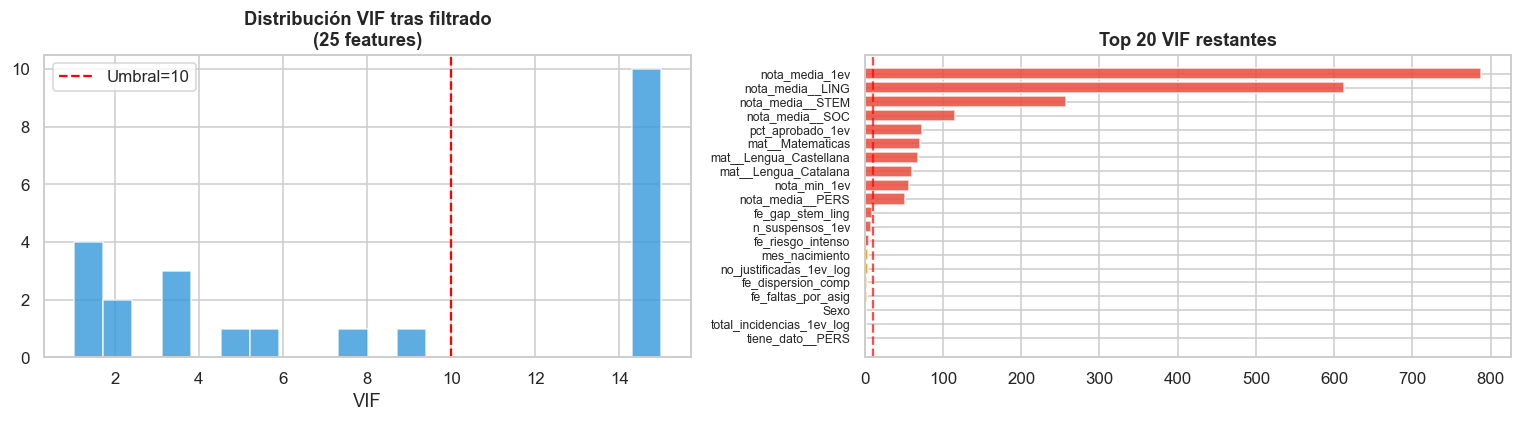

In [4]:
# Visualizar distribución de VIF final
vif_final = calcular_vif(X_vif, features_vif)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(vif_final['VIF'].clip(upper=15), bins=20, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(UMBRAL_VIF, color='red', linestyle='--', label=f'Umbral={UMBRAL_VIF}')
axes[0].set_xlabel('VIF')
axes[0].set_title(f'Distribución VIF tras filtrado\n({len(features_vif)} features)', fontweight='bold')
axes[0].legend()

# Top 20 VIF restantes
top20 = vif_final.head(20)
colors_bar = ['#e74c3c' if v > 5 else '#f39c12' if v > 3 else '#2ecc71'
              for v in top20['VIF']]
axes[1].barh(range(len(top20)), top20['VIF'], color=colors_bar, alpha=0.85)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20['feature'], fontsize=8)
axes[1].invert_yaxis()
axes[1].axvline(UMBRAL_VIF, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Top 20 VIF restantes', fontweight='bold')

plt.tight_layout()
plt.show()

## Paso 2 — Permutation Importance con CV

La importancia de permutación mide cuánto cae el F1 cuando se aleatoriza una feature.  
Ventaja sobre la importancia de impureza (gini): no favorece features de alta cardinalidad y es válida para features correlacionadas.

Se calcula con RF sobre cada fold de CV (para evitar leakage).

In [5]:
# Permutation importance promediada sobre los 5 folds de CV
X_vif_tv = X_vif  # ya es solo X_tv, filtrado por VIF

rf_ref = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)

perm_imp_folds = np.zeros(len(features_vif))

for fold_i, (train_idx, val_idx) in enumerate(CV.split(X_vif_tv, y_tv)):
    rf_ref.fit(X_vif_tv[train_idx], y_tv[train_idx])
    pi = permutation_importance(
        rf_ref, X_vif_tv[val_idx], y_tv[val_idx],
        n_repeats=10, scoring=scorer_academico, random_state=SEED, n_jobs=-1
    )
    perm_imp_folds += pi.importances_mean

perm_imp_mean = perm_imp_folds / CV.n_splits

pi_df = (pd.DataFrame({'feature': features_vif, 'perm_importance': perm_imp_mean})
           .sort_values('perm_importance', ascending=False))

print(f'Features con perm_importance > 0    : {(pi_df["perm_importance"] > 0).sum()}')
print(f'Features con perm_importance <= 0   : {(pi_df["perm_importance"] <= 0).sum()}  ← candidatas a eliminar')
print(f'\nTop 25:')
print(pi_df.head(25).to_string(index=False))

Features con perm_importance > 0    : 12
Features con perm_importance <= 0   : 13  ← candidatas a eliminar

Top 25:
                  feature  perm_importance
          n_suspensos_1ev            0.006
         pct_aprobado_1ev            0.004
       fe_faltas_por_asig            0.003
  no_justificadas_1ev_log            0.003
             nota_min_1ev            0.002
       fe_dispersion_comp            0.002
         mat__Matematicas            0.001
         nota_media__STEM            0.001
          nota_media__SOC            0.001
           nota_media_1ev            0.001
         nota_media__LING            0.000
         HermanosPosicion            0.000
                tiene_NEE            0.000
            sin_notas_1ev            0.000
         fe_triple_riesgo            0.000
              IsRepetidor            0.000
           mes_nacimiento           -0.000
     mat__Lengua_Catalana           -0.000
   mat__Lengua_Castellana           -0.000
         nota_media__PER

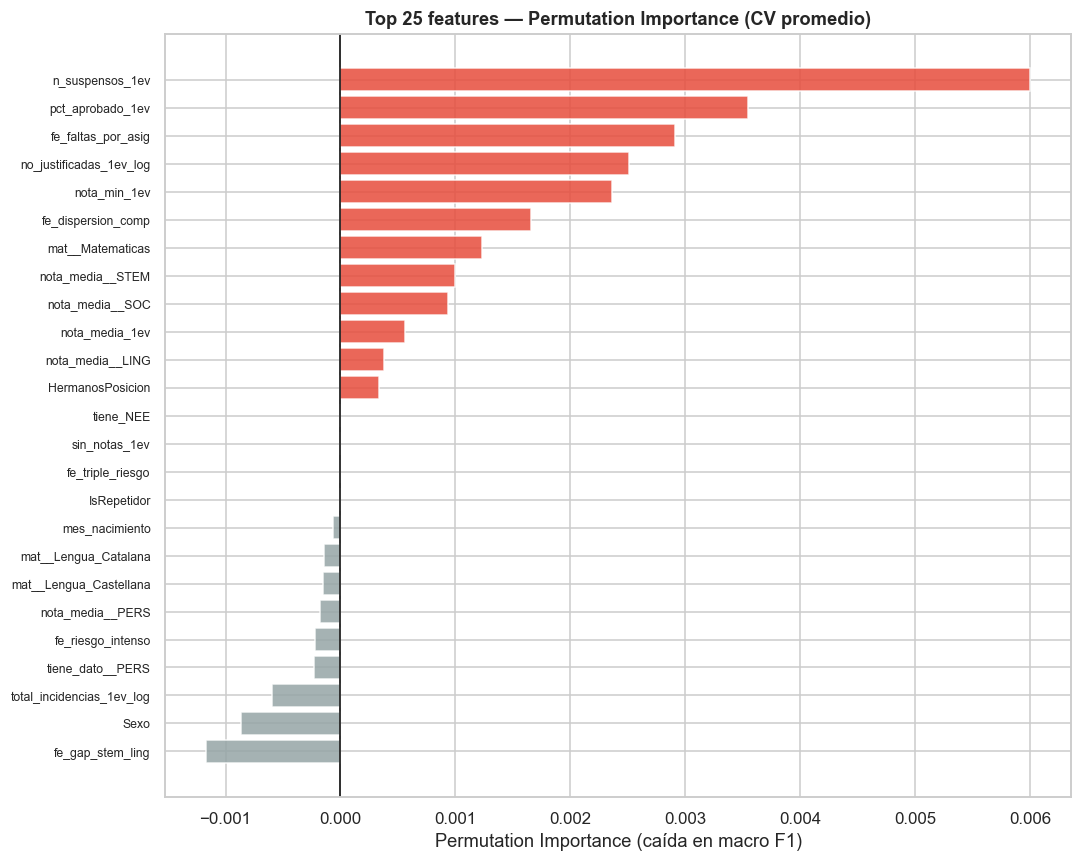


Features con importancia > 0: 12


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(35, len(pi_df))
top_pi = pi_df.head(top_n)
colors_pi = ['#e74c3c' if v > 0 else '#95a5a6' for v in top_pi['perm_importance']]
ax.barh(range(top_n), top_pi['perm_importance'], color=colors_pi, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_pi['feature'], fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Permutation Importance (caída en macro F1)')
ax.set_title(f'Top {top_n} features — Permutation Importance (CV promedio)', fontweight='bold')
plt.tight_layout()
plt.show()

# Features a retener: importancia > 0
features_perm = pi_df[pi_df['perm_importance'] > 0]['feature'].tolist()
print(f'\nFeatures con importancia > 0: {len(features_perm)}')

## Paso 3 — RFECV: selección recursiva con CV

RFECV elimina iterativamente las features menos importantes usando CV para determinar el número óptimo.  
Parte del conjunto ya filtrado por VIF.

In [7]:
rf_rfe = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=3,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)

rfecv = RFECV(
    estimator=rf_rfe,
    step=1,
    cv=CV,
    scoring=scorer_academico,
    min_features_to_select=5,
    n_jobs=-1
)
rfecv.fit(X_vif_tv, y_tv)

n_optimo = rfecv.n_features_
features_rfe = [f for f, sel in zip(features_vif, rfecv.support_) if sel]

print(f'Número óptimo de features (RFECV): {n_optimo}')
print(f'Features seleccionadas:')
for f in features_rfe:
    print(f'  {f}')

Número óptimo de features (RFECV): 24
Features seleccionadas:
  nota_media_1ev
  nota_min_1ev
  n_suspensos_1ev
  pct_aprobado_1ev
  IsRepetidor
  Sexo
  mes_nacimiento
  HermanosPosicion
  nota_media__LING
  nota_media__PERS
  nota_media__SOC
  nota_media__STEM
  mat__Lengua_Castellana
  mat__Lengua_Catalana
  mat__Matematicas
  total_incidencias_1ev_log
  no_justificadas_1ev_log
  tiene_dato__PERS
  sin_notas_1ev
  tiene_NEE
  fe_riesgo_intenso
  fe_faltas_por_asig
  fe_dispersion_comp
  fe_gap_stem_ling


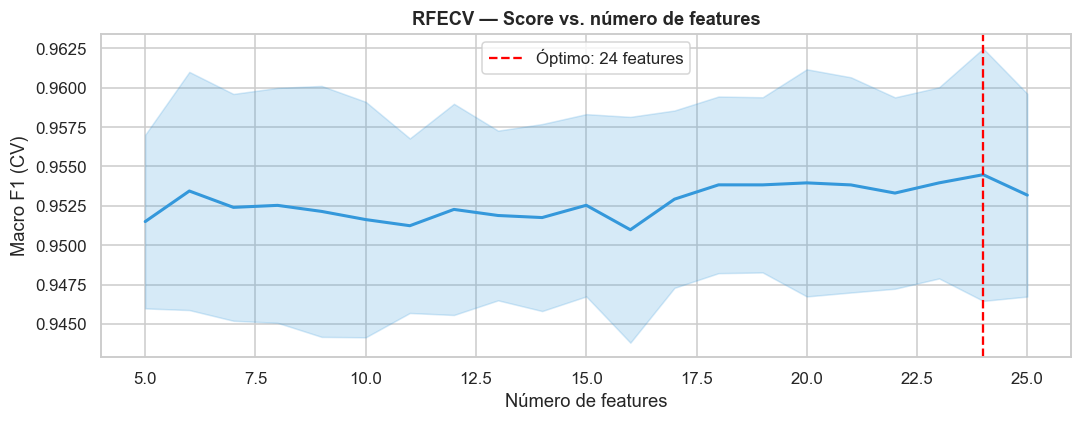

In [8]:
# Curva de score vs número de features
cv_scores = rfecv.cv_results_['mean_test_score']
cv_stds   = rfecv.cv_results_['std_test_score']
n_range   = range(rfecv.min_features_to_select,
                  rfecv.min_features_to_select + len(cv_scores))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_range, cv_scores, color='#3498db', linewidth=2)
ax.fill_between(n_range,
                np.array(cv_scores) - np.array(cv_stds),
                np.array(cv_scores) + np.array(cv_stds),
                alpha=0.2, color='#3498db')
ax.axvline(n_optimo, color='red', linestyle='--',
           label=f'Óptimo: {n_optimo} features')
ax.set_xlabel('Número de features')
ax.set_ylabel('Macro F1 (CV)')
ax.set_title('RFECV — Score vs. número de features', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Paso 4 — Comparar subconjuntos de features

In [9]:
def cv_f1(features_lista, X_full, nombres_full, y, cv):
    """Evalúa un subconjunto de features con CV sobre X_tv."""
    idx = [nombres_full.index(f) for f in features_lista if f in nombres_full]
    X_sub = X_full[:, idx]
    rf = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    )
    scores = cross_val_score(rf, X_sub, y, cv=cv, scoring=scorer_academico, n_jobs=-1)
    return scores.mean(), scores.std()

# Subconjuntos a comparar
subconjuntos = {
    f'Todas las features ({len(feat_cols)})': feat_cols,
    f'Tras VIF>10 ({len(features_vif)})': features_vif,
    f'Perm. Importance >0 ({len(features_perm)})': features_perm,
    f'RFECV óptimo ({len(features_rfe)})': features_rfe,
}

# Para "todas" usamos X_tv original (sin filtro VIF)
resultados_sel = []
feat_cols_list = list(feat_cols)

for nombre, features in subconjuntos.items():
    # Determinar cuál X base usar
    base_X = X_tv
    base_names = feat_cols_list
    media, std = cv_f1(features, base_X, base_names, y_tv, CV)
    print(f'  {nombre:<45}: {media:.3f} ± {std:.3f}')
    resultados_sel.append({'subconjunto': nombre, 'n_features': len(features),
                           'f1_val': media, 'f1_val_std': std})

res_sel_df = pd.DataFrame(resultados_sel)

  Todas las features (54)                      : 0.953 ± 0.007


  Tras VIF>10 (25)                             : 0.953 ± 0.005


  Perm. Importance >0 (12)                     : 0.953 ± 0.007


  RFECV óptimo (24)                            : 0.954 ± 0.006


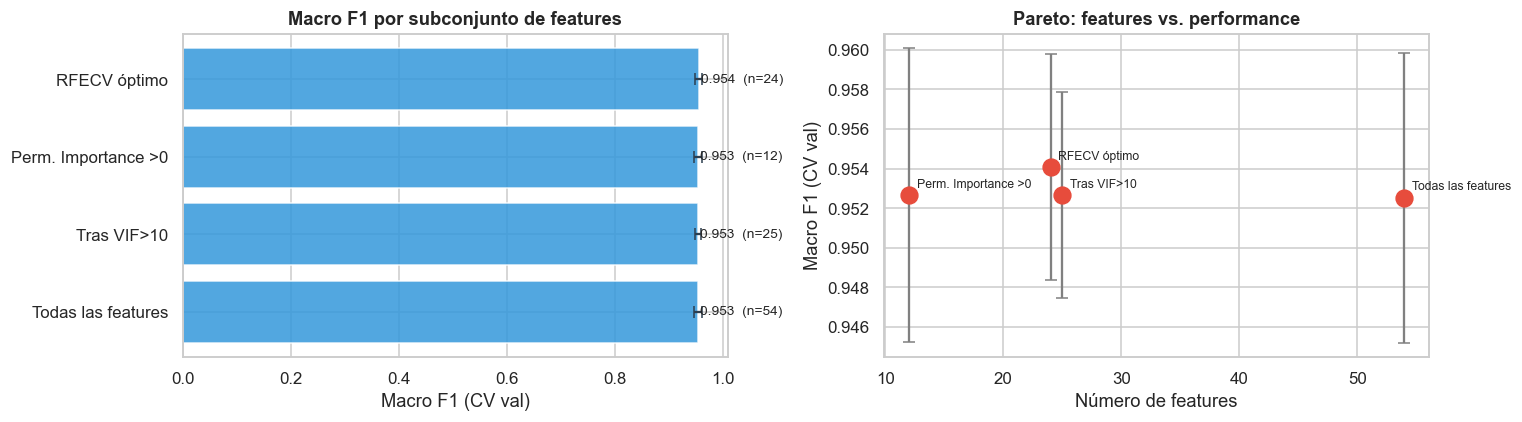

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# F1 por subconjunto
nombres_cortos = [s.split('(')[0].strip() for s in res_sel_df['subconjunto']]
axes[0].barh(range(len(res_sel_df)), res_sel_df['f1_val'],
             xerr=res_sel_df['f1_val_std'], color='#3498db', alpha=0.85,
             capsize=4, error_kw={'ecolor': '#2c3e50'})
axes[0].set_yticks(range(len(res_sel_df)))
axes[0].set_yticklabels(nombres_cortos)
axes[0].set_xlabel('Macro F1 (CV val)')
axes[0].set_title('Macro F1 por subconjunto de features', fontweight='bold')
for i, (f1, n) in enumerate(zip(res_sel_df['f1_val'], res_sel_df['n_features'])):
    axes[0].text(f1 + 0.005, i, f'{f1:.3f}  (n={n})', va='center', fontsize=9)

# Pareto: más features no siempre = mejor
axes[1].scatter(res_sel_df['n_features'], res_sel_df['f1_val'],
                s=120, color='#e74c3c', zorder=3)
axes[1].errorbar(res_sel_df['n_features'], res_sel_df['f1_val'],
                 yerr=res_sel_df['f1_val_std'], fmt='none', color='gray', capsize=4)
for _, row in res_sel_df.iterrows():
    axes[1].annotate(row['subconjunto'].split('(')[0].strip(),
                     (row['n_features'], row['f1_val']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Número de features')
axes[1].set_ylabel('Macro F1 (CV val)')
axes[1].set_title('Pareto: features vs. performance', fontweight='bold')

plt.tight_layout()
plt.show()

## Paso 5 — Elegir subconjunto final y guardar

In [11]:
# Estrategia: elegir el subconjunto con mejor f1_val.
# En caso de empate técnico (diferencia < 0.01), preferir el más pequeño (parsimonia).
mejor_idx = res_sel_df['f1_val'].idxmax()
mejor_f1  = res_sel_df.loc[mejor_idx, 'f1_val']

# Entre los que están a <= 0.01 del mejor, tomar el de menos features
candidatos  = res_sel_df[res_sel_df['f1_val'] >= mejor_f1 - 0.01]
elegido_idx = candidatos['n_features'].idxmin()
elegido_nombre = res_sel_df.loc[elegido_idx, 'subconjunto']

subconjunto_final = subconjuntos[elegido_nombre]

print(f'Subconjunto elegido: {elegido_nombre}')
print(f'  F1 val: {res_sel_df.loc[elegido_idx, "f1_val"]:.3f} ± {res_sel_df.loc[elegido_idx, "f1_val_std"]:.3f}')
print(f'  Features: {len(subconjunto_final)}')

# ── Guardar JSON con metadatos de selección ───────────────────────────────────
P_OUT_FEATURES = BASE_DIR / 'data' / 'selected_features_v11.json'
resultado_json = {
    'metodo': elegido_nombre,
    'n_features_original': len(feat_cols),
    'n_features_seleccionadas': len(subconjunto_final),
    'features': list(subconjunto_final),
    'vif_eliminadas': eliminadas_vif,
    'rfecv_n_optimo': int(n_optimo),
}
with open(P_OUT_FEATURES, 'w', encoding='utf-8') as fj:
    json.dump(resultado_json, fj, indent=2, ensure_ascii=False)
print(f'\nJSON guardado: {P_OUT_FEATURES}')

# ── Guardar CSV reducido — lo que carga directamente el notebook 05 ───────────
P_OUT_CSV = BASE_DIR / 'data' / 'dataset_v11_sel.csv'
cols_conservar = list(subconjunto_final) + ['target_num', 'categoria_target']
# Filtrar solo columnas que existen en el df original
cols_conservar = [c for c in cols_conservar if c in df.columns]
df[cols_conservar].to_csv(P_OUT_CSV, index=False)
print(f'CSV reducido guardado: {P_OUT_CSV}')
print(f'  Shape: {df[cols_conservar].shape}  ({len(subconjunto_final)} features + 2 target)')

Subconjunto elegido: Perm. Importance >0 (12)
  F1 val: 0.953 ± 0.007
  Features: 12

JSON guardado: C:\Users\emili\OneDrive\Escritorio\TFM\data\selected_features_v11.json
CSV reducido guardado: C:\Users\emili\OneDrive\Escritorio\TFM\data\dataset_v11_sel.csv
  Shape: (1205, 14)  (12 features + 2 target)


## Resumen

In [12]:
print('=== Pipeline de selección de features ===')
print(f'  Features originales        : {len(feat_cols)}')
print(f'  Tras VIF > {UMBRAL_VIF}             : {len(features_vif)}  (-{len(feat_cols)-len(features_vif)})')
print(f'  Tras Perm. Importance > 0  : {len(features_perm)}  (-{len(features_vif)-len(features_perm)})')
print(f'  RFECV óptimo               : {len(features_rfe)}')
print(f'  SELECCIÓN FINAL            : {len(subconjunto_final)}')
print(f'\n  → El notebook 07 carga selected_features_v11.json para usar este subconjunto.')

=== Pipeline de selección de features ===
  Features originales        : 54
  Tras VIF > 10             : 25  (-29)
  Tras Perm. Importance > 0  : 12  (-13)
  RFECV óptimo               : 24
  SELECCIÓN FINAL            : 12

  → El notebook 07 carga selected_features_v11.json para usar este subconjunto.
